In [17]:
import os
import shutil
import cv2
from PIL import Image
import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, Sequential
from keras.utils import image_dataset_from_directory
from tensorflow import data as tf_data
#import pydot
from numpy import ndarray
import hashlib
import imagehash

In [ ]:
# model building imports
from keras import Model, Sequential, Input

from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.layers import LeakyReLU
from keras.ops import add
from keras.utils import to_categorical

: 

In [ ]:
# model training imports
from keras.optimizers import SGD
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy, AUC, F1Score
from keras.callbacks import ModelCheckpoint, CSVLogger, LearningRateScheduler

: 

## Importing Data

In [ ]:
n_classes = 23
batch_size = 64
input_shape = (512, 512, 3)
image_size = (512, 512)

: 

In [ ]:
#podem não ser imagens -- ver se são brancas e pretas (são 0 e 1 e não servem)
#mudar o background
#duplicados
#quantas imagens ha por autor
#podemos fzr rotação de imagens para não ser tendicioso

: 

In [ ]:
data = image_dataset_from_directory(
    "wikiart_datasets",
    label_mode= "categorical",
    batch_size= batch_size,
    image_size= image_size,
    interpolation= "bilinear",
    verbose= False
)

: 

# Data Quality Assessment

In [ ]:
#see classes
class_names = data.class_names
print(class_names)

['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


: 

In [ ]:
count = [len(os.listdir(f"wikiart_datasets/{c}")) for c in class_names]

for class_name, number in zip(class_names, count):
    print(f"Author {class_name} has {number} paintings")

Author Albrecht_Durer has 580 paintings
Author Boris_Kustodiev has 444 paintings
Author Camille_Pissarro has 621 paintings
Author Childe_Hassam has 385 paintings
Author Claude_Monet has 934 paintings
Author Edgar_Degas has 428 paintings
Author Eugene_Boudin has 389 paintings
Author Gustave_Dore has 528 paintings
Author Ilya_Repin has 378 paintings
Author Ivan_Aivazovsky has 404 paintings
Author Ivan_Shishkin has 364 paintings
Author John_Singer_Sargent has 549 paintings
Author Marc_Chagall has 536 paintings
Author Martiros_Saryan has 403 paintings
Author Nicholas_Roerich has 1274 paintings
Author Pablo_Picasso has 534 paintings
Author Paul_Cezanne has 406 paintings
Author Pierre_Auguste_Renoir has 975 paintings
Author Pyotr_Konchalovsky has 644 paintings
Author Raphael_Kirchner has 362 paintings
Author Rembrandt has 544 paintings
Author Salvador_Dali has 336 paintings
Author Vincent_van_Gogh has 1322 paintings


: 

In [ ]:
max_count = max(count)
min_count = min(count)

max_author = class_names[count.index(max_count)]
min_author = class_names[count.index(min_count)]

print(f"Max: {max_count} paintings by {max_author}")
print(f"Min: {min_count} paintings by {min_author}")

Max: 1322 paintings by Vincent_van_Gogh
Min: 336 paintings by Salvador_Dali


: 

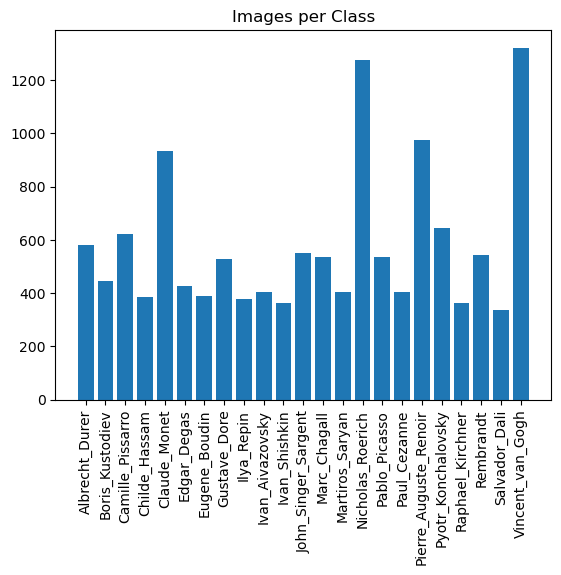

: 

In [ ]:
plt.bar(class_names, count)
plt.xticks(rotation=90)
plt.title("Images per Class")
plt.show()

In [ ]:
#BRILHO E SATURAÇÃO

brightness_issues = []
low_variance_images = []

for root, _, files in os.walk("wikiart_datasets"):
    for file in files:
        path = os.path.join(root, file)
        
        try:
            with Image.open(path) as img:
                img = img.convert("RGB")
                img_array = np.asarray(img)
            
            # Brilho
            mean_val = np.mean(img_array)  #pixels vão de 0 a 255
            if mean_val < 30 or mean_val > 220:     #perto de 0 muito escuro, perto de 255 muito claro
                brightness_issues.append(path)
            
            # Saturação (variação de cor) 
            std_val = np.std(img_array)
            if std_val < 10:   #baixo -- imagem uniforme, alto -- imagem com detalhe
                low_variance_images.append(path)
        
        except:
            continue

print("Brightness issues:", len(brightness_issues))
print("Low variance images:", len(low_variance_images))

Brightness issues: 175
Low variance images: 0


: 

In [ ]:
# NON RGB IMAGES

grayscale_images = []

for root, _, files in os.walk("wikiart_datasets"):
    for file in files:
        path = os.path.join(root, file)
        
        try:
            with Image.open(path) as img:
                img = img.convert("RGB")
                img_array = np.asarray(img)
            
            if np.allclose(img_array[:,:,0], img_array[:,:,1]) and np.allclose(img_array[:,:,1], img_array[:,:,2]):
                grayscale_images.append(path)
        
        except:
            continue

print("Grayscale images:", len(grayscale_images))

Grayscale images: 889


: 

In [ ]:
count = [len(os.listdir(f"wikiart_datasets/{c}")) for c in class_names]

count_gray = [sum(1 for path in grayscale_images if os.path.basename(os.path.dirname(path)) == c) for c in class_names]

plt.bar(class_names, count_gray)
plt.xticks(rotation=90)
plt.title("Grayscale Images per Class")
plt.show()

In [13]:
valid_extensions = (".jpg", ".jpeg", ".png")

def assess_dataset(folder):
    hashes = {}
    
    invalid_files = []
    zerobyte_files = []
    corrupted_files = []
    naninf_images = []
    duplicate_files = []
    
    for root, _, files in os.walk(folder):
        for file in files:
            path = os.path.join(root, file)
            
            # 1. Extensão inválida
            if not file.lower().endswith(valid_extensions):
                invalid_files.append(path)
                continue
            
            # 2. Zero-byte
            if os.path.getsize(path) == 0:
                zerobyte_files.append(path)
                continue
            
            try:
                # 3. Abrir imagem + verificar corrupção -- se for inválido vai para o except
                with Image.open(path) as img:
                    img.verify()

                # Reabrir imagem -- verify() “invalida” o objeto da imagem; tens de abrir outra vez para usar
                with Image.open(path) as img:
                    img = img.convert("RGB")    # garantir consistência
                    img.load()         # força leitura completa, apanha erros que o verify não

                img_array = np.asarray(img)  #converte imagem em array para podermos analisar os pixels
                
                # 4. Verificar valores inválidos (deteta Nan, +infinito, -infinito)
                if not np.isfinite(img_array).all():
                    naninf_images.append(path)
                    continue

                # 5. Hash para duplicados
                img_hash = imagehash.phash(img)  #diferencia imagens visualmente iguais
    
                if img_hash in hashes:
                    duplicate_files.append((path, hashes[img_hash])) #guardamos as 2 que achamos que são duplicados
                else:
                    hashes[img_hash] = path
            
            except Exception:
                corrupted_files.append(path)
    
    print("=== Data Quality Report ===")
    print(f"Invalid files: {len(invalid_files)}")
    print(f"Empty files: {len(zerobyte_files)}")
    print(f"Corrupted images: {len(corrupted_files)}")
    print(f"Invalid images: {len(naninf_images)}")
    print(f"Duplicate images: {len(duplicate_files)}")
    
    return {
        "invalid": invalid_files,
        "empty": zerobyte_files,
        "corrupted": corrupted_files,
        "nan_inf": naninf_images,
        "duplicates": duplicate_files
    }

In [14]:
report = assess_dataset("wikiart_datasets")

=== Data Quality Report ===
Invalid files: 0
Empty files: 0
Corrupted images: 0
Invalid images: 0
Duplicate images: 12


In [15]:
duplicates = report['duplicates']  #values of key duplicates in report

In [ ]:
def get_author(path):
    return os.path.basename(os.path.dirname(path))

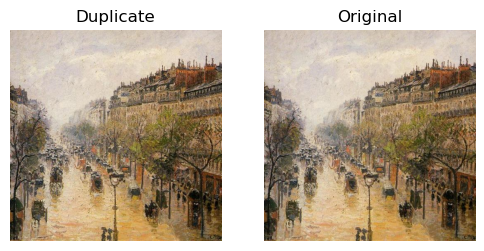

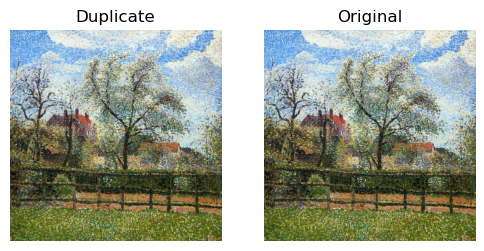

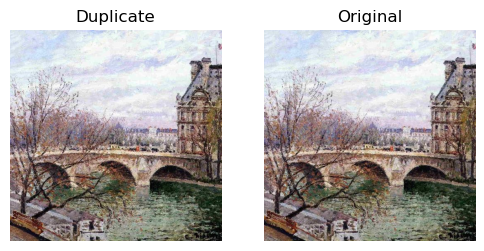

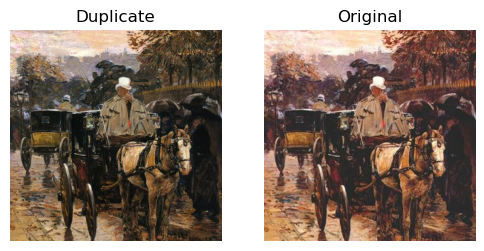

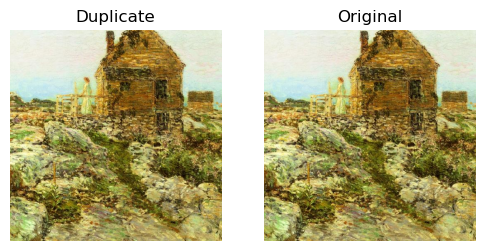

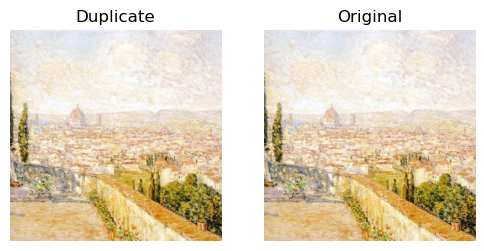

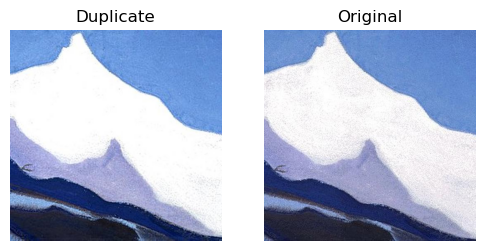

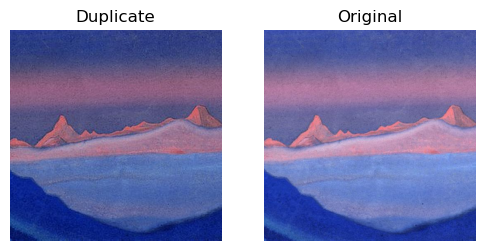

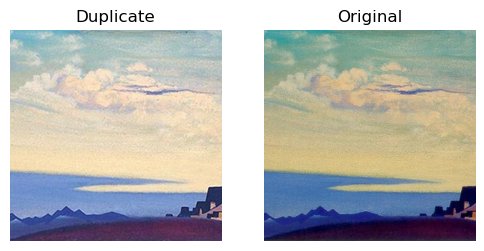

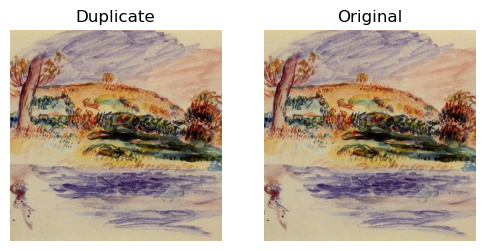

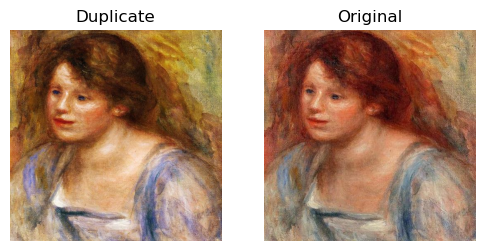

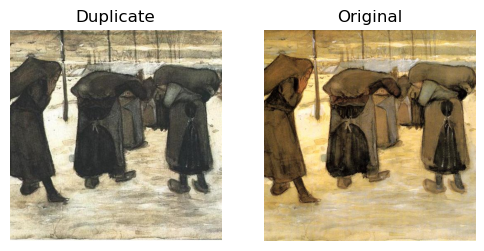

In [16]:
for dup, original in duplicates:
    plt.figure(figsize=(6,3))
    
    plt.subplot(1,2,1)
    plt.imshow(Image.open(dup))
    plt.title("Duplicate")
    plt.axis("off")
    
    plt.subplot(1,2,2)
    plt.imshow(Image.open(original))
    plt.title("Original")
    plt.axis("off")
    
    plt.show()